# Unit-5 Support Vector Machine

A Support Vector Machine (SVM) is a powerful and versatile supervised machine learning model used for both classification and regression. However, it is most famous for its ability to handle complex classification tasks.

At its core, an SVM looks for the optimal hyperplane that best separates different classes in a dataset.

### 1. Introduction to SVM
The Support Vector Machine (SVM) is a supervised learning algorithm used for classification. The goal is to find the Optimal Hyperplane that separates data points of different classes with the maximum possible margin.

### 2. Core Concepts
- **Hyperplane:** The decision boundary that separates the classes. In 2D, it is a line; in 3D, it is a plane.
- **Support Vectors:** The data points closest to the hyperplane. They "support" the plane; if they move, the plane moves.
- **Margin:** The distance between the hyperplane and the nearest data points (support vectors). SVM tries to maximize this margin.

### 3. The Mathematical Formula
The equation of the hyperplane is:
wx + b =0

Where:
- w is the weight vector (normal to the hyperplane).
- x is the input feature vector.
- b is the bias (offset).


Real-world data is rarely perfectly separable by a straight line. If the data is a jumbled mess in 2D, the SVM uses a Kernel Function to project the data into a higher dimension (3D or more).

In this higher-dimensional space, a flat plane can suddenly separate the classes easily. Once the math is done, the model projects the result back down to your original space, resulting in a non-linear (curved) boundary.

### Common kernels include:

**Linear:** For simple, linearly separable data.

**Polynomial:** For curved boundaries.

**RBF (Radial Basis Function):** The most popular choice; it can handle highly complex, overlapping data.

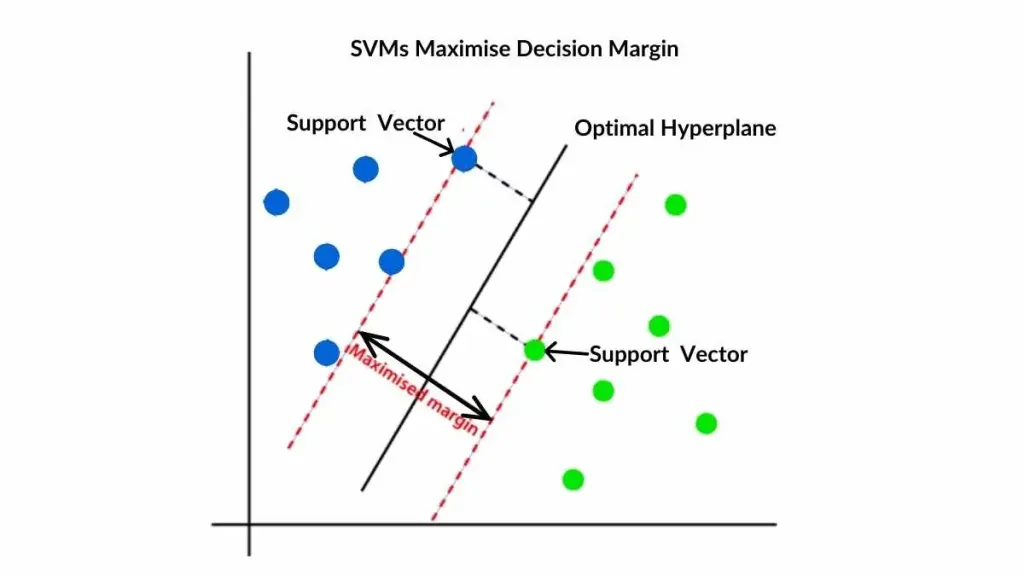

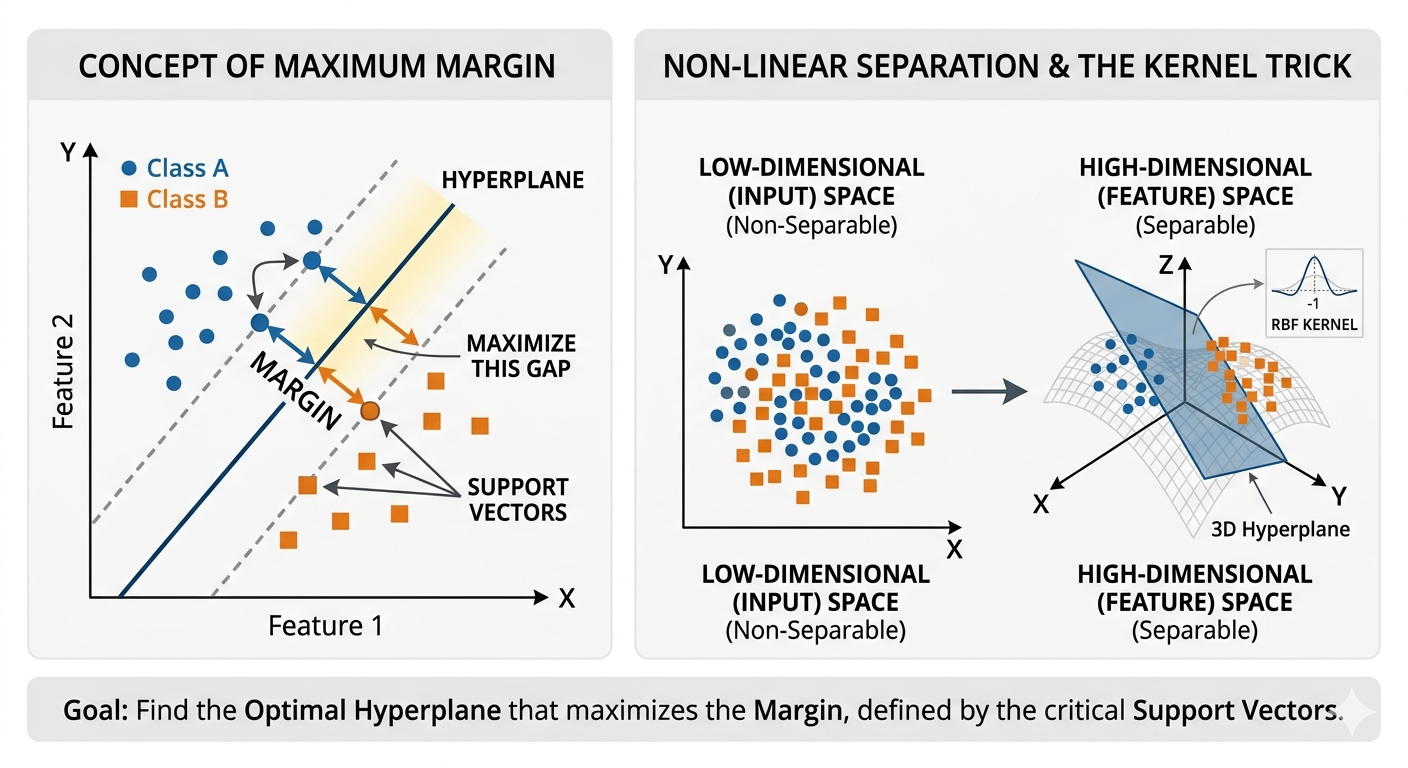

In Support Vector Machines, C is a hyperparameter that acts as a "penalty" or "regulator." It tells the SVM how much you care about misclassifying each individual training example versus how much you want a smooth, wide boundary.

Think of C as the "Strictness" parameter. C is most commonly called the Regularization Parameter.

#### How C Works
The SVM objective function tries to balance two things:

**Maximizing the Margin:** Keeping the "road" between classes as wide as possible.

**Minimizing Classification Error:** Ensuring all points are on the correct side of the boundary.

C determines the trade-off between these two.

**Low C** 

- Goal: Prioritize a large margin even if some points are misclassified.
- Behavior: The model is more tolerant of outliers. It looks for a simpler, "cleaner" line that captures the general trend.

**High C** 

- Goal: Prioritize zero misclassification (or as close as possible).
- Behavior: The model will bend and squeeze the margin to make sure every single point is on the right side.

In [19]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [20]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [22]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [23]:
x=df.iloc[:,0:8]
y=df.iloc[:,-1]

In [24]:
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [14]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [31]:
from sklearn.svm import SVC
classifier = SVC(kernel='rbf', C=1.0, random_state=1)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)
print(y_pred)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


In [32]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")

Model Accuracy: 78.57%


In [33]:
classifier = SVC(kernel='rbf', C=5.0, random_state=1) #for C=5
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")

Model Accuracy: 79.87%


In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[94  5]
 [26 29]]


In [35]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,y_pred))
print("Specificity:",recall_score(y_test,y_pred,pos_label=0))

Sensitivity: 0.5272727272727272
Specificity: 0.9494949494949495


In [37]:
from sklearn.metrics import precision_score
print("Precision Score (Positive):",precision_score(y_test,y_pred))
print("Precision Score (Negative):",precision_score(y_test,y_pred,pos_label=0))

Precision Score (Positive): 0.8529411764705882
Precision Score (Negative): 0.7833333333333333
